In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

In [3]:
print("LINEAR REGRESSION (CLUSTERING)")

LINEAR REGRESSION (CLUSTERING)


In [ ]:
data=load_diabetes()

X=data.data #il cluster lavora solo sulle feature, non ha label y

df=pd.DataFrame(X,columns=data.feature_names)



In [8]:
#kmean usa distanza euclidea, le variabili devono essere scalate
#nel dataset diabetes le feature sono già standarizzate, quindi siamo a posto
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X)
labels=kmeans.labels_
#labels contiene il cluster assegnato a ogni paziente


In [ ]:
#aggiungo i cluster al DataFrame
#df=pd.DataFrame(X,columns=data.feature_names)
df["cluster"]=labels #clusetr è il raggruppamento dei clienti, generato da Kmeans
df["target"]=data.target #contiene il valore reale della progressione della malattia
#target è già nel dataset iniziale
#è interessasnte confrontare cluster con target per capire se i gruppi trovati con KMeans
#hanno significato rispetto alla progressione della malattia (target)
print(df.groupby("cluster")["target"].mean())
#se i cluster hanno medie target molto diverse, significa che
#le feature riescono a separare gruppi con diversa progressione della malattia
#anche senza supervision

cluster
0    108.968553
1    196.715447
2    160.756250
Name: target, dtype: float64


In [9]:
#guardiamo anche la varianza, se le medie sono molto diverse rispetto alla deviazione
#standard, allora c'è separazone
df.groupby("cluster")["target"].agg(["mean","std","count"])

,mean,std,count
cluster,,,
0,108.968553,55.563104,159
1,196.715447,67.968595,123
2,160.756250,79.976392,160


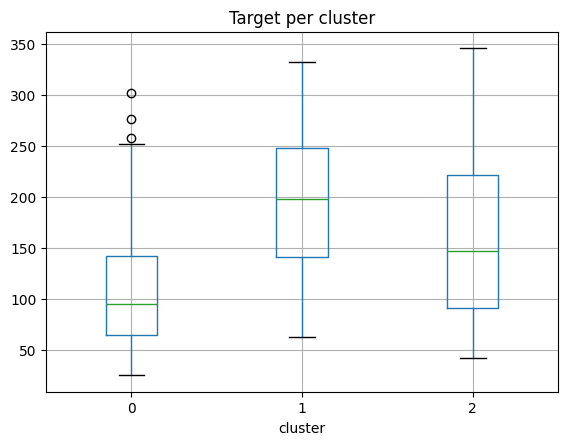

In [10]:
#boxplot
import matplotlib.pyplot as plt

df.boxplot(column="target", by="cluster")
plt.title("Target per cluster")
plt.suptitle("")
plt.show()

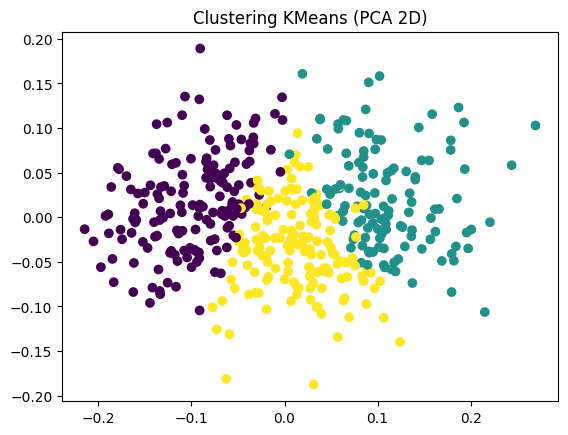

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap="viridis")
plt.title("Clustering KMeans (PCA 2D)")
plt.show()

#esistono gruppi naturali di pazienti con caratteristiche simili
#non sta prevedendo nulla, sta solo segmentando